# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Diego Fernando Marin, 2024

# 03_EDA
Proyecto: **Identificación temprana del riesgo de deserción estudiantil en CEFIT**

---

Este cuaderno realiza el **Análisis Exploratorio de Datos (EDA)** sobre los datos limpios de CEFIT. El objetivo es comprender el perfil de los estudiantes, descubrir patrones asociados a la no continuidad y preparar los datos para el modelo.

Cada bloque sigue la estructura: **Pregunta → Código → Respuesta → Conclusión / Hipótesis**.

**Variable objetivo:** *Riesgo de no continuidad* (`Categoria`), construida en `02_limpieza`:
- **No continuidad:** Desertor, Inactivo, Cancelado, Retiro - Aplazados.
- **Continuidad:** Activo, Graduado, Egresado.
- **Por validar:** Sancionado, Aplazamientos, Sin estado.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', None)

In [2]:
cwd = os.getcwd()  # current working directory
trusted_dir = cwd + '/../data/trusted/'

In [3]:
df = pd.read_csv(trusted_dir + 'datos_limpios.csv', parse_dates=['Fecha de Matrícula'])
df.shape

(13461, 23)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13461 entries, 0 to 13460
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   Género                   13461 non-null  str                
 1   Municipio de Nacimiento  13461 non-null  str                
 2   País                     13461 non-null  str                
 3   Municipio Dirección      13407 non-null  str                
 4   Barrio Dirección         13461 non-null  str                
 5   Estrato                  12193 non-null  float64            
 6   Estado civil             13461 non-null  str                
 7   EPS                      13460 non-null  str                
 8   Grupo Sisben             13461 non-null  str                
 9   Zona                     12160 non-null  str                
 10  Nivel de formación       13461 non-null  str                
 11  Ocupación                11543 non-null

In [5]:
df.describe(include='all').T.head(25)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Género,13461,3,Masculino,7141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Municipio de Nacimiento,13461,399,Medellín,4553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
País,13461,3,Colombia,13408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Municipio Dirección,13407,27,Envigado,11091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Barrio Dirección,13461,319,Sin dato,1372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estrato,12193.0,NaN,NaN,NaN,2.57205,0.0,2.0,3.0,3.0,6.0,0.732571
Estado civil,13461,9,Soltero(a),9761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPS,13460,75,EPS Sura,4989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grupo Sisben,13461,58,Sin dato,10347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zona,12160,4,Urbana,10867,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Para los análisis de **tasa de no continuidad** trabajamos solo con los registros clasificables
(Continuidad / No continuidad) y definimos una función auxiliar.

In [6]:
clasif = df[df['Categoria'].isin(['Continuidad', 'No continuidad'])].copy()

def tasa_no_continuidad(columna, datos=clasif, min_n=0):
    g = datos.groupby(columna)['Categoria']
    tasa = g.apply(lambda s: (s == 'No continuidad').mean() * 100)
    n = datos[columna].value_counts()
    out = pd.DataFrame({'Estudiantes': n, 'Tasa_no_continuidad_%': tasa.round(1)})
    return out[out['Estudiantes'] >= min_n].sort_values('Tasa_no_continuidad_%', ascending=False)

print('Tasa global de no continuidad: %.1f%%' %
      ((clasif['Categoria'] == 'No continuidad').mean() * 100))

Tasa global de no continuidad: 46.1%


---
# A. Análisis univariante — perfil de los estudiantes

**Pregunta 1:** ¿Cómo se distribuyen los estudiantes según su Estado académico y la categoría de continuidad?

In [7]:
tabla = pd.DataFrame({'Registros': df['Estado'].value_counts(),
                      'Porcentaje_%': (df['Estado'].value_counts()/len(df)*100).round(2)})
tabla

,Registros,Porcentaje_%
Estado,,
Inactivo,4838,35.94
Graduado,3831,28.46
Activo,2808,20.86
Cancelado,759,5.64
Sancionado,602,4.47
Aplazamiento Semestre,285,2.12
Sin estado,243,1.81
Desertor,79,0.59
Aplazamiento Actividades,8,0.06


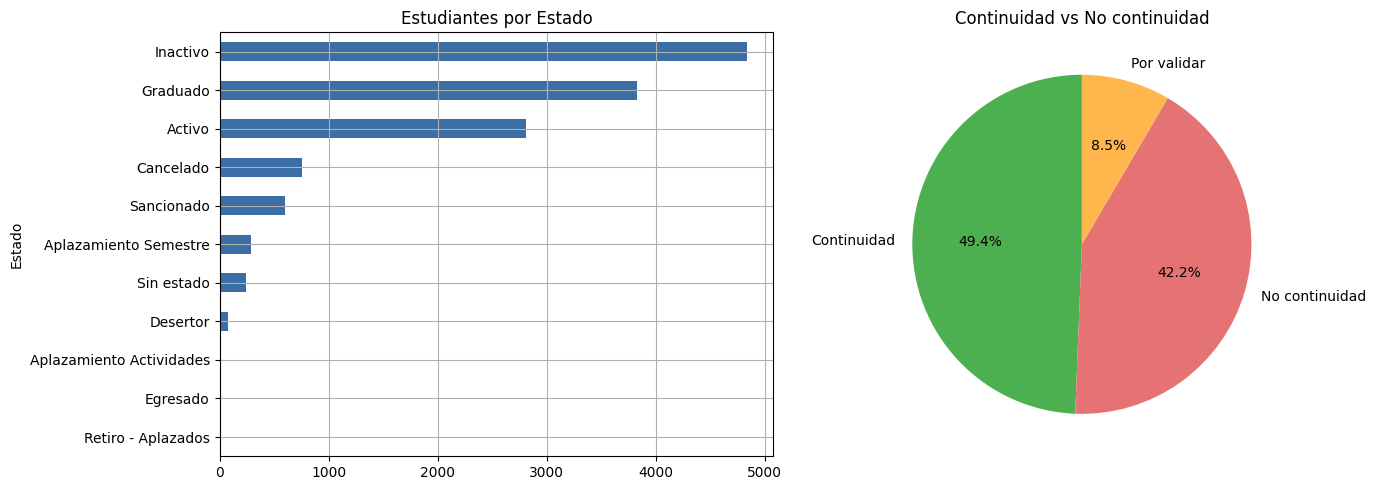

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df['Estado'].value_counts().plot(kind='barh', ax=ax[0], color='#3b6ea5')
ax[0].set_title('Estudiantes por Estado'); ax[0].invert_yaxis()
df['Categoria'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
    colors=['#4caf50', '#e57373', '#ffb74d'], startangle=90)
ax[1].set_title('Continuidad vs No continuidad'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()

**Respuesta:** los estados más frecuentes son *Inactivo* (35,9 %), *Graduado* (28,5 %) y *Activo* (20,9 %). Agrupados: **49,4 % continuidad**, **42,2 % no continuidad** y 8,5 % por validar.

**Conclusión:** la no continuidad está dominada por "Inactivo", que probablemente mezcla deserción real con cierres administrativos. *Hipótesis:* validar con CEFIT el significado de "Inactivo" reducirá la tasa real de deserción; el 42,2 % es un techo, no la deserción efectiva.

**Pregunta 2:** ¿Cómo se distribuyen los estudiantes por Género?

Género
Masculino     7141
Femenino      6319
Sin genero       1
Name: count, dtype: int64


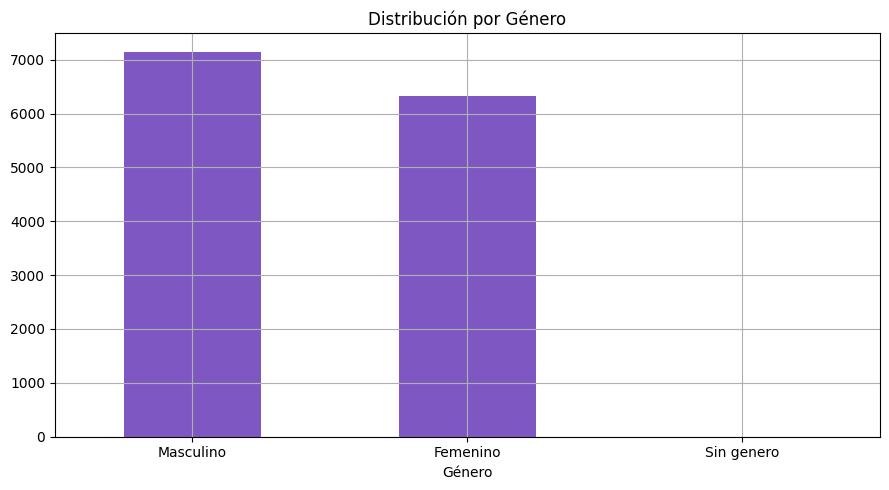

In [9]:
print(df['Género'].value_counts())
df['Género'].value_counts().plot(kind='bar', color='#7e57c2', rot=0)
plt.title('Distribución por Género'); plt.tight_layout(); plt.show()

**Respuesta:** población equilibrada: ~53 % masculino y ~47 % femenino (más un registro "Sin genero").

**Conclusión:** no hay sesgo fuerte de género en la matrícula. *Hipótesis:* el género por sí solo no explicará la deserción, pero conviene cruzarlo con el estado (Pregunta 15).

**Pregunta 3:** ¿Cómo se distribuye la Edad de los estudiantes?

count    13441.0
mean        28.4
std         11.2
min          1.0
25%         20.0
50%         26.0
75%         34.0
max         79.0
Name: Edad, dtype: float64


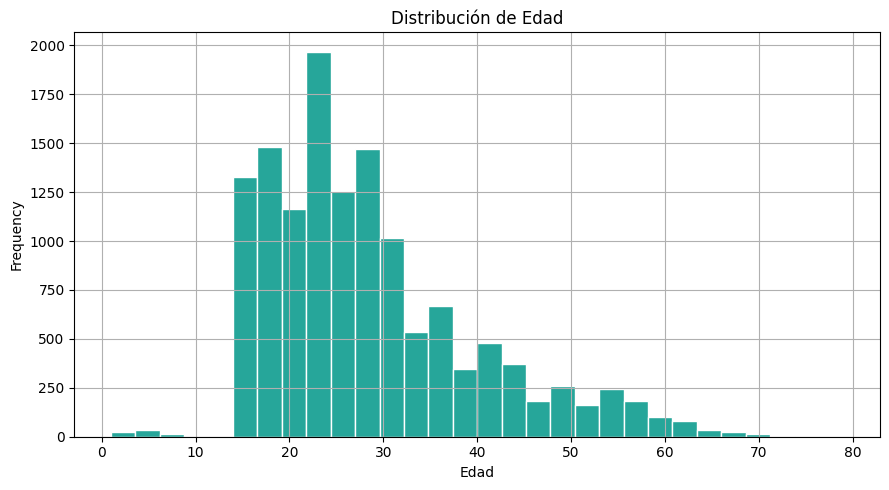

In [10]:
print(df['Edad'].describe().round(1))
df['Edad'].dropna().plot(kind='hist', bins=30, color='#26a69a', edgecolor='white')
plt.title('Distribución de Edad'); plt.xlabel('Edad'); plt.tight_layout(); plt.show()

**Respuesta:** edad mediana de **26 años**, con la mayoría entre 20 y 34 (tras corregir las edades imposibles en la limpieza).

**Conclusión:** el estudiante típico es un adulto joven. *Hipótesis:* es población que probablemente trabaja o busca empleo, lo que sugiere que la flexibilidad horaria y el apoyo socioeconómico influyen en la permanencia.

**Pregunta 4:** ¿Cómo se distribuyen los estudiantes por Estrato socioeconómico?

Estrato
0.0      46
1.0     392
2.0    5326
3.0    5591
4.0     673
5.0     138
6.0      27
NaN    1268
Name: count, dtype: int64


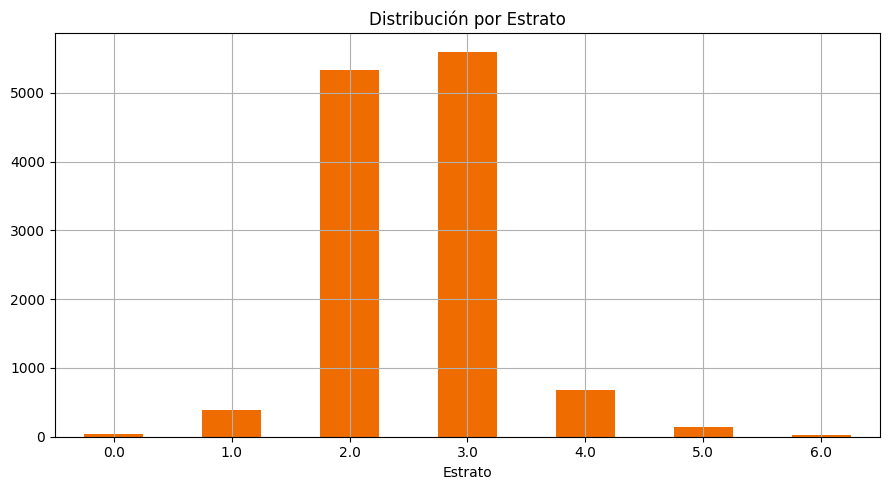

In [11]:
print(df['Estrato'].value_counts(dropna=False).sort_index())
df['Estrato'].value_counts().sort_index().plot(kind='bar', color='#ef6c00', rot=0)
plt.title('Distribución por Estrato'); plt.tight_layout(); plt.show()

**Respuesta:** concentración fuerte en **estratos 2 y 3** (más del 80 % de quienes reportan estrato); muy pocos en estratos 5 y 6.

**Conclusión:** perfil socioeconómico medio-bajo. *Hipótesis:* los factores económicos pesan en la continuidad; las estrategias de retención deberían contemplar apoyo financiero.

**Pregunta 5:** ¿Cómo se distribuyen los estudiantes por Zona (urbana / rural)?

Zona
Urbana            10867
NaN                1301
Rural               831
Urbana - rural      436
Sin dato             26
Name: count, dtype: int64


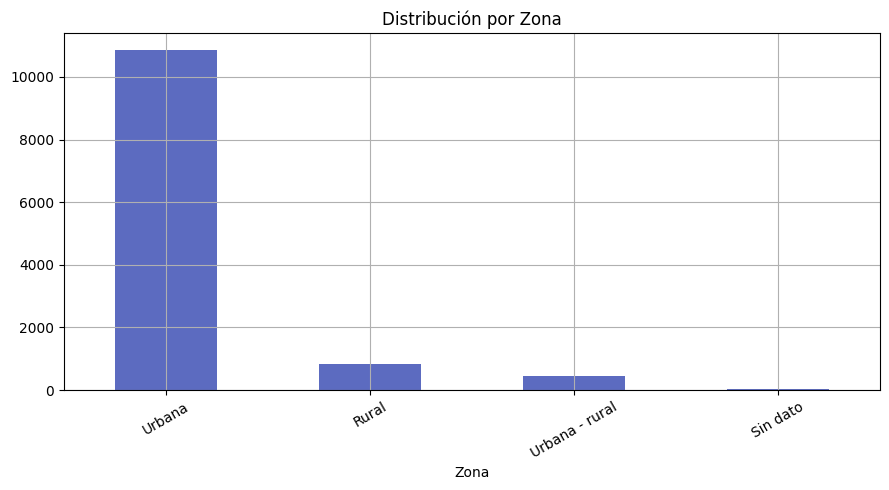

In [12]:
print(df['Zona'].value_counts(dropna=False))
df['Zona'].value_counts().plot(kind='bar', color='#5c6bc0', rot=30)
plt.title('Distribución por Zona'); plt.tight_layout(); plt.show()

**Respuesta:** predominio de **zona urbana** (~90 % de los que reportan zona), con una minoría rural.

**Conclusión:** CEFIT atiende sobre todo población urbana de Envigado y el área metropolitana. *Hipótesis:* la zona tendrá efecto limitado por el bajo número de casos rurales.

**Pregunta 6:** ¿Cuál es la distribución de estudiantes por Jornada?

Jornada
NOCHE            6293
DIURNA           4255
MEDIA TÉCNICA    2759
NaN               123
SÁBADOS            26
TARDE               5
Name: count, dtype: int64


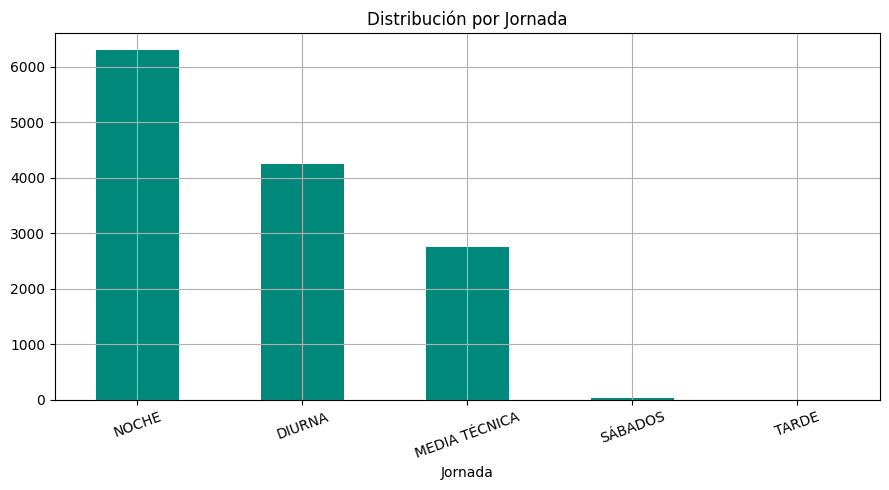

In [13]:
print(df['Jornada'].value_counts(dropna=False))
df['Jornada'].value_counts().plot(kind='bar', color='#00897b', rot=20)
plt.title('Distribución por Jornada'); plt.tight_layout(); plt.show()

**Respuesta:** la jornada **Noche** es la más numerosa, seguida de **Diurna** y **Media Técnica**.

**Conclusión:** el peso de la jornada nocturna refuerza la hipótesis de estudiantes que trabajan de día. *Hipótesis:* la jornada será una variable clave del riesgo (ver Pregunta 13).

**Pregunta 7:** ¿Cuáles son los programas con mayor número de estudiantes?

Programas distintos: 78


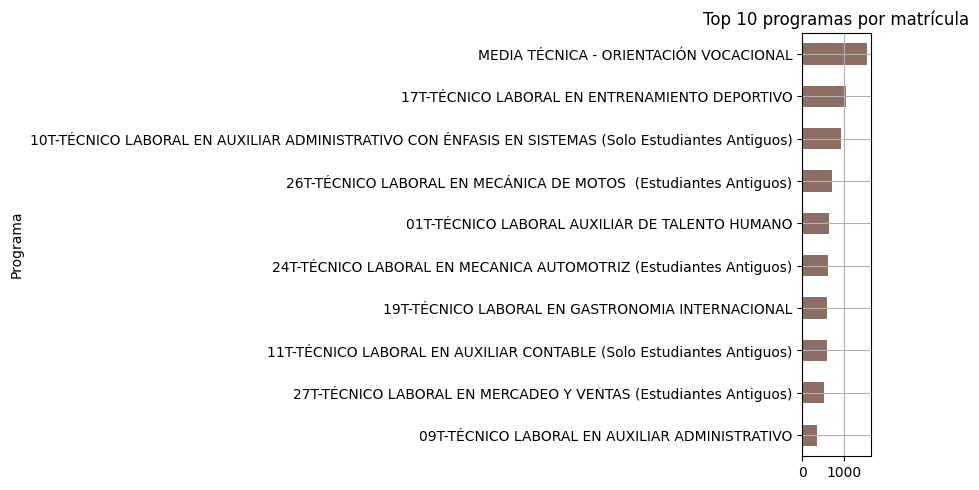

In [14]:
print('Programas distintos:', df['Programa'].nunique())
df['Programa'].value_counts().head(10).plot(kind='barh', color='#8d6e63')
plt.title('Top 10 programas por matrícula'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

**Respuesta:** hay **78 programas** distintos. Los más grandes son *Media Técnica - Orientación Vocacional*, *Entrenamiento Deportivo* y los técnicos administrativos/sistemas.

**Conclusión:** la oferta está muy fragmentada y varios programas figuran como "antiguos". *Hipótesis:* parte de esos 78 son duplicados o programas descontinuados que conviene estandarizar antes de modelar.

**Pregunta 8:** ¿Cuál es la distribución por Ocupación?

Ocupación
Estudiante superior    3624
Empleado               2753
Estudiante básica      2372
NaN                    1918
Desempleado            1740
Independiente          1007
Sin dato                 47
Name: count, dtype: int64


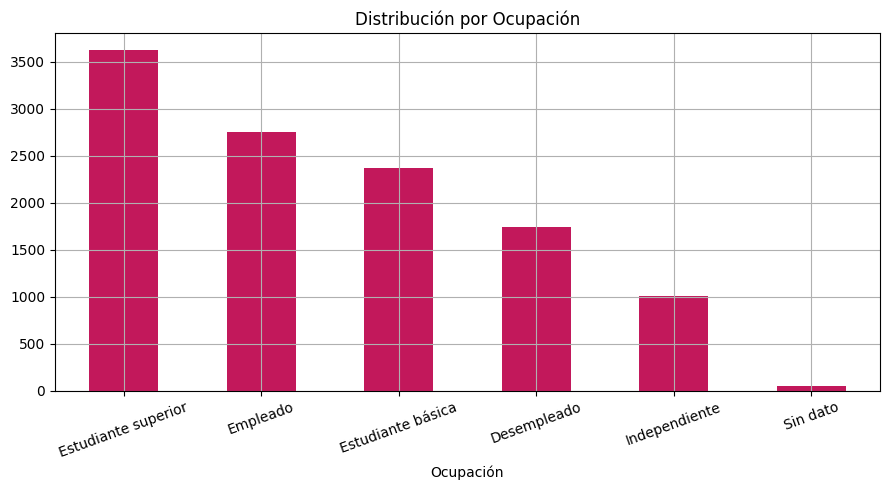

In [15]:
print(df['Ocupación'].value_counts(dropna=False))
df['Ocupación'].value_counts().plot(kind='bar', color='#c2185b', rot=20)
plt.title('Distribución por Ocupación'); plt.tight_layout(); plt.show()

**Respuesta:** predominan *Estudiante superior*, *Empleado* y *Estudiante básica*; también hay un grupo relevante de *Desempleados* e *Independientes*. La ocupación tiene ~1.900 nulos.

**Conclusión:** coexisten estudiantes que ya trabajan con otros en formación. *Hipótesis:* la ocupación se relaciona con la continuidad (ver Pregunta 19).

**Pregunta 9:** ¿Cómo se distribuye el Nivel de formación?

In [16]:
df['Nivel de formación'].value_counts(dropna=False).head(8)

Nivel de formación
Media                6819
Sin dato             3396
Básica secundaria    2102
Básica Secundaria     519
Pregrado              489
Postgrado              80
Básica primaria        38
Básica Primaria         9
Name: count, dtype: int64

**Respuesta:** la mayoría está en nivel *Media*, seguido de *Básica secundaria*; hay muchos *"Sin respuesta"* y aparece la categoría duplicada *"Básica secundaria"* vs *"Básica Secundaria"* (distinta capitalización).

**Conclusión:** existe un problema de estandarización de categorías. *Hipótesis:* unificar mayúsculas/minúsculas mejorará la calidad del análisis y del modelo.

**Pregunta 10:** ¿Cuál es la distribución por Estado civil?

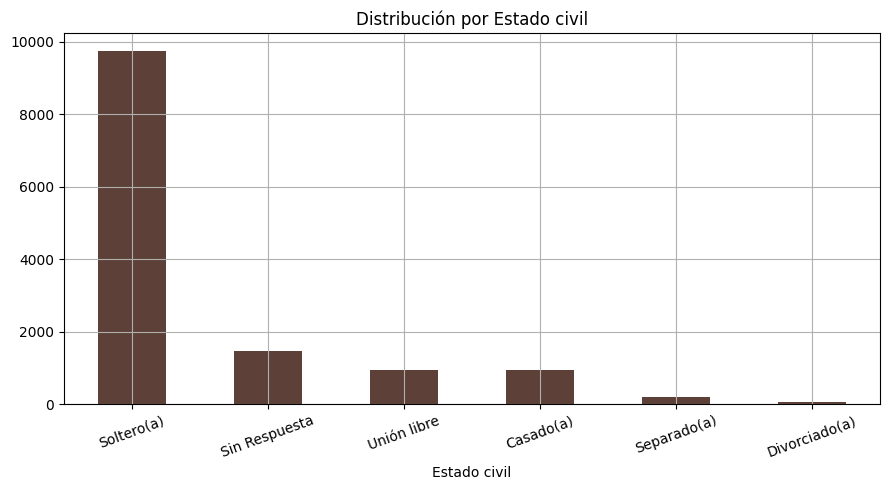

Estado civil
Soltero(a)       9761
Sin Respuesta    1456
Unión libre       954
Casado(a)         944
Separado(a)       206
Divorciado(a)      57
Name: count, dtype: int64

In [17]:
df['Estado civil'].value_counts(dropna=False).head(6).plot(kind='bar', color='#5d4037', rot=20)
plt.title('Distribución por Estado civil'); plt.tight_layout(); plt.show()
df['Estado civil'].value_counts(dropna=False).head(6)

**Respuesta:** la gran mayoría son **solteros(as)**; siguen *Unión libre* y *Casado(a)*.

**Conclusión:** coherente con la edad joven de la población. *Hipótesis:* el estado civil aportará poca capacidad predictiva por su baja variabilidad.

**Pregunta 11:** ¿Cuál es el medio de transporte más utilizado?

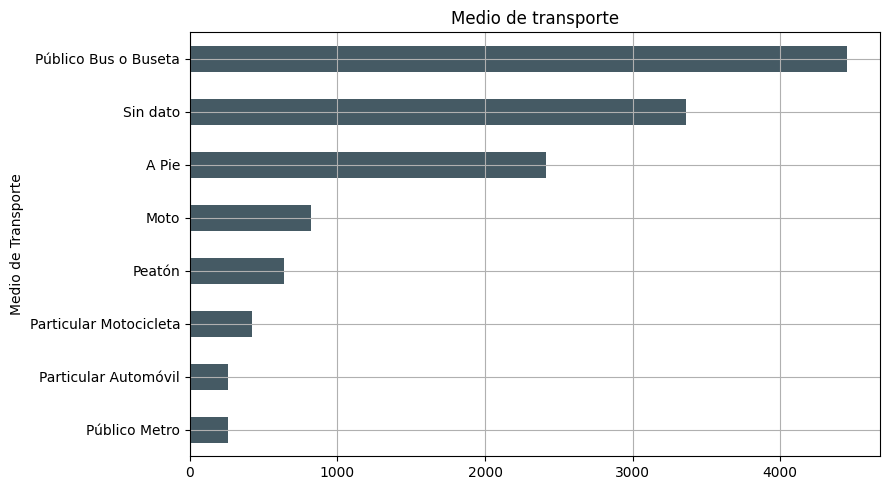

Medio de Transporte
Público Bus o Buseta      4453
Sin dato                  3363
A Pie                     2413
Moto                       818
Peatón                     637
Particular Motocicleta     423
Particular Automóvil       257
Público Metro              255
Name: count, dtype: int64

In [18]:
df['Medio de Transporte'].value_counts(dropna=False).head(8).plot(kind='barh', color='#455a64')
plt.title('Medio de transporte'); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
df['Medio de Transporte'].value_counts(dropna=False).head(8)

**Respuesta:** predomina el **transporte público (bus/buseta)** y desplazarse **a pie**; hay muchos *"Sin respuesta"*.

**Conclusión:** acceso dependiente de transporte público o cercanía. *Hipótesis:* la distancia/medio de transporte podría asociarse a la deserción, pero el alto número de faltantes limita su uso.

**Pregunta 12:** ¿De qué municipios provienen los estudiantes (dirección)?

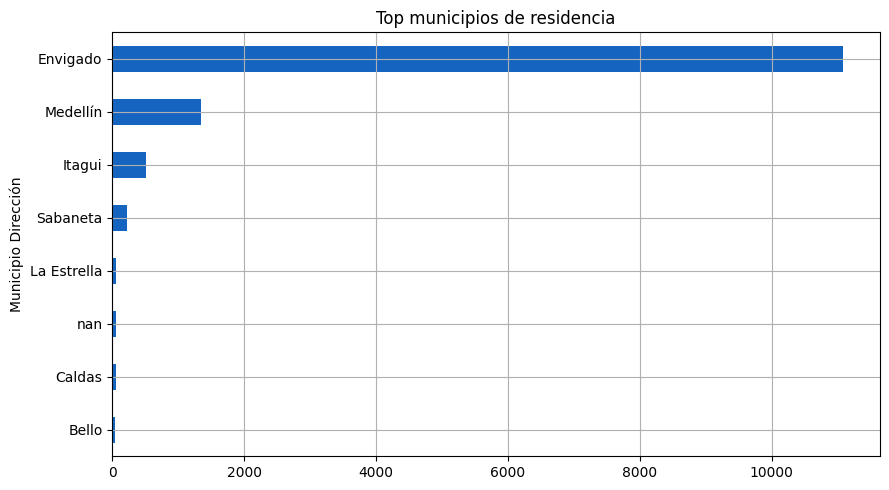

Municipio Dirección
Envigado       11091
Medellín        1352
Itagui           508
Sabaneta         219
La Estrella       62
NaN               54
Caldas            53
Bello             45
Name: count, dtype: int64

In [19]:
df['Municipio Dirección'].value_counts(dropna=False).head(8).plot(kind='barh', color='#1565c0')
plt.title('Top municipios de residencia'); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
df['Municipio Dirección'].value_counts(dropna=False).head(8)

**Respuesta:** la enorme mayoría reside en **Envigado**, seguido de **Medellín** e **Itagüí**.

**Conclusión:** CEFIT es una institución de fuerte arraigo local. *Hipótesis:* los estudiantes de municipios más lejanos podrían tener mayor riesgo por costos/tiempos de desplazamiento.

---
# B. Relación de las variables con la no continuidad

**Pregunta 13:** ¿Qué jornadas concentran la mayor tasa de no continuidad?

,Estudiantes,Tasa_no_continuidad_%
Jornada,,
MEDIA TÉCNICA,2682,74.3
NOCHE,5644,40.0
DIURNA,3868,33.7


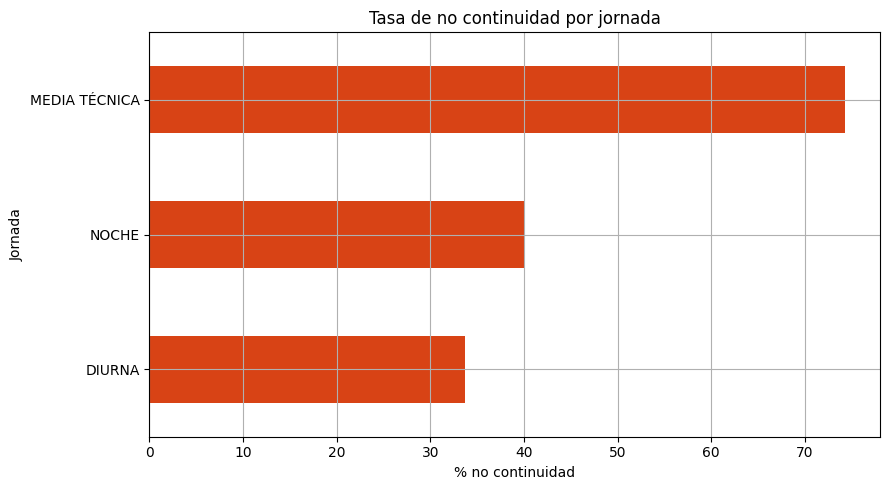

In [20]:
t13 = tasa_no_continuidad('Jornada', min_n=20)
display(t13)
t13['Tasa_no_continuidad_%'].sort_values().plot(kind='barh', color='#d84315')
plt.title('Tasa de no continuidad por jornada'); plt.xlabel('% no continuidad')
plt.tight_layout(); plt.show()

**Respuesta:** **Media Técnica** tiene la tasa más alta (~74 %), seguida de **Noche** (~40 %) y **Diurna** (~34 %).

**Conclusión:** las jornadas no son homogéneas. *Hipótesis:* la altísima tasa de Media Técnica es en parte un artefacto (estudiantes de colegio cuyo "inactivo" = fin de ciclo); conviene analizarla aparte de Noche y Diurna, donde la no continuidad sí refleja riesgo real.

**Pregunta 14:** ¿Qué programas presentan mayor y menor tasa de no continuidad?

In [21]:
prog = tasa_no_continuidad('Programa', min_n=100)
print('TOP 5 mayor no continuidad:'); display(prog.head(5))
print('TOP 5 menor no continuidad:'); display(prog.tail(5))

TOP 5 mayor no continuidad:


,Estudiantes,Tasa_no_continuidad_%
Programa,,
MEDIA TÉCNICA MECÁNICA MOTOS,118,89.0
MEDIA TÉCNICA - ORIENTACIÓN VOCACIONAL,1539,88.5
MEDIA TECNICA TECNICO LABORAL EN ENTRENAMIENTO DEPORTIVO,326,69.0
TÉCNICO LABORAL EN ELECTRÓNICA Y ELECTRICIDAD AUTOMOTRIZ,203,62.1
MEDIA TÉCNICA MERCADEO Y VENTAS,172,59.9


TOP 5 menor no continuidad:


,Estudiantes,Tasa_no_continuidad_%
Programa,,
18T-TÉCNICO LABORAL EN GASTRONOMÍA,136,17.6
12T-TÉCNICO LABORAL EN AUXILIAR DE RECURSO HUMANO,120,17.5
22T-TÉCNICO LABORAL EN MARKETING DIGITAL,222,16.2
EXTENSIÓN - BIOSEGURIDAD,250,6.0
EXTENSIÓN MANIPULACIÓN DE ALIMENTOS,149,0.0


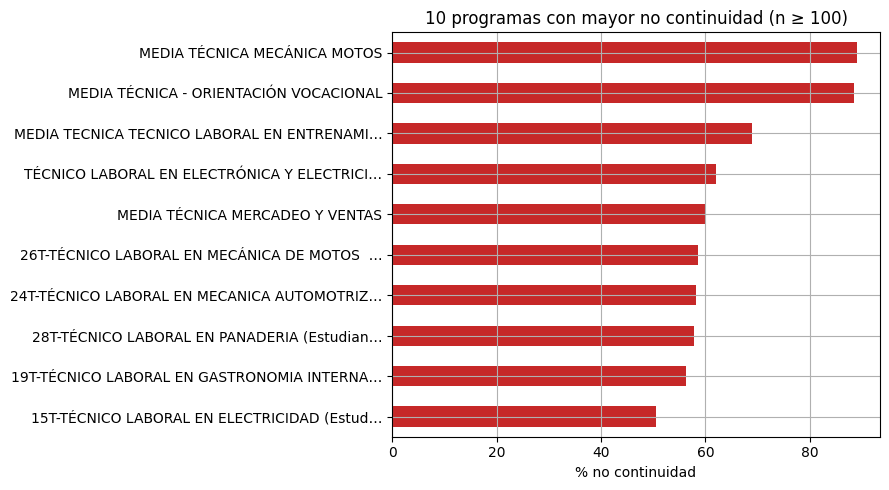

In [22]:
top = prog.head(10).copy()
top.index = [n[:42] + '…' if len(n) > 42 else n for n in top.index]
top['Tasa_no_continuidad_%'].sort_values().plot(kind='barh', color='#c62828')
plt.title('10 programas con mayor no continuidad (n ≥ 100)'); plt.xlabel('% no continuidad')
plt.tight_layout(); plt.show()

**Respuesta:** los de mayor riesgo son de **Media Técnica** y técnicos antiguos (mecánica de motos, orientación vocacional, entrenamiento deportivo), por encima del 60 %. Las mejores tasas de permanencia son los cursos de **extensión** (manipulación de alimentos, bioseguridad) y técnicos como *Marketing Digital* y *Gastronomía*.

**Conclusión:** el riesgo se concentra en pocos programas. *Hipótesis:* los cursos cortos de extensión retienen mejor por su duración; priorizar acompañamiento en la franja superior daría el mayor retorno.

**Pregunta 15:** ¿Existe relación entre el Género y la continuidad?

Categoria,Continuidad,No continuidad,Por validar
Género,,,
Femenino,54.4,37.6,8.0
Masculino,44.9,46.2,8.9
Sin genero,0.0,100.0,0.0


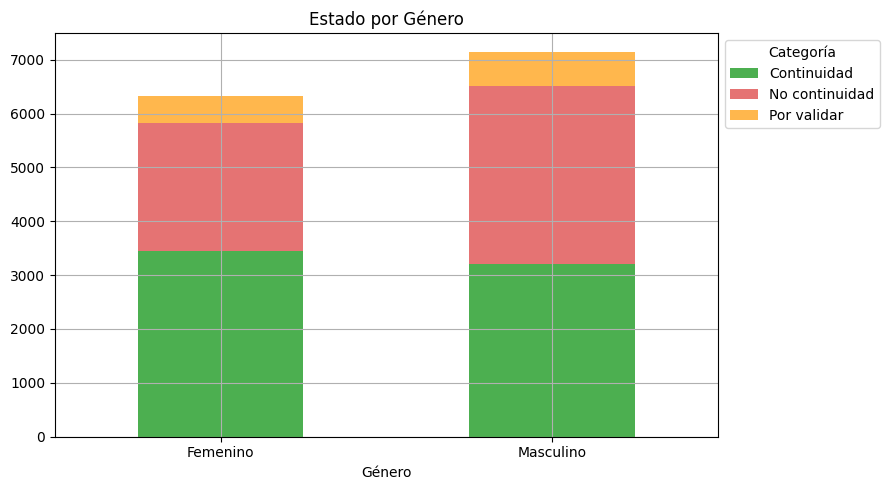

In [23]:
tab15 = pd.crosstab(df['Género'], df['Categoria'], normalize='index').round(3) * 100
display(tab15)
ct = pd.crosstab(df['Género'], df['Categoria'])
ct = ct.loc[ct.sum(axis=1) > 5]
ct.plot(kind='bar', stacked=True, color=['#4caf50', '#e57373', '#ffb74d'], rot=0)
plt.title('Estado por Género'); plt.legend(title='Categoría', bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

**Respuesta:** las mujeres muestran más continuidad (~54 %) que los hombres (~45 %); los hombres tienen más no continuidad (~46 % vs ~38 %).

**Conclusión:** hay una diferencia moderada por género. *Hipótesis:* el género será una predictora secundaria útil, pero no determinante por sí sola.

**Pregunta 16:** ¿La Edad se relaciona con la continuidad?

Categoria
Continuidad       27.0
No continuidad    24.0
Name: Edad, dtype: float64


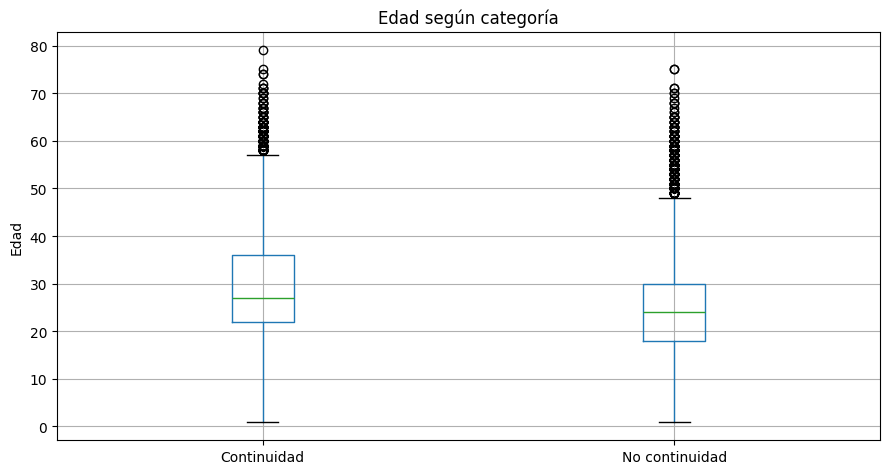

In [24]:
print(clasif.groupby('Categoria')['Edad'].median())
clasif.boxplot(column='Edad', by='Categoria')
plt.title('Edad según categoría'); plt.suptitle(''); plt.xlabel(''); plt.ylabel('Edad')
plt.tight_layout(); plt.show()

**Respuesta:** la edad mediana en no continuidad (24 años) es algo menor que en continuidad (27 años).

**Conclusión:** ser más joven se asocia a algo más de no continuidad. *Hipótesis:* esto refleja en parte a los estudiantes de Media Técnica (más jóvenes); la edad aporta señal moderada al modelo.

**Pregunta 17:** ¿El Estrato se relaciona con la no continuidad?

,Estudiantes,Tasa_no_continuidad_%
Estrato,,
5.0,134,57.5
1.0,362,50.6
4.0,622,49.8
3.0,5095,48.7
2.0,4811,45.9
0.0,44,9.1


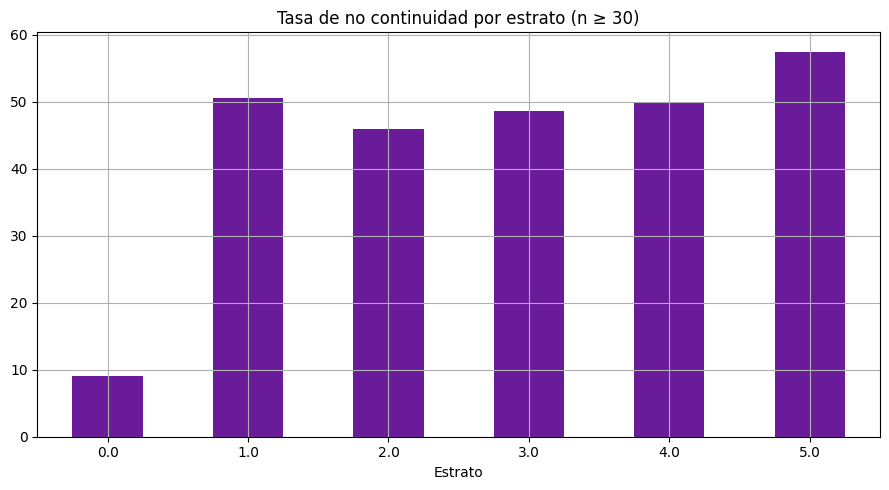

In [25]:
t17 = tasa_no_continuidad('Estrato', min_n=30)
display(t17)
t17['Tasa_no_continuidad_%'].sort_index().plot(kind='bar', color='#6a1b9a', rot=0)
plt.title('Tasa de no continuidad por estrato (n ≥ 30)'); plt.xlabel('Estrato')
plt.tight_layout(); plt.show()

**Respuesta:** la tasa no es estrictamente creciente ni decreciente; en los estratos 2–4 (donde está la mayoría) ronda el 46–50 %. Los estratos 5 y 6 muestran tasas altas pero con **muy pocos casos**, por lo que no son concluyentes.

**Conclusión:** el estrato, por sí solo, no separa claramente el riesgo. *Hipótesis:* su efecto aparece combinado con jornada y programa más que de forma aislada.

**Pregunta 18:** ¿La Zona de residencia se relaciona con la no continuidad?

In [26]:
t18 = tasa_no_continuidad('Zona', min_n=30)
display(t18)

,Estudiantes,Tasa_no_continuidad_%
Zona,,
Rural,758,51.6
Urbana - rural,393,49.6
Urbana,9885,47.3


**Respuesta:** la zona **rural** tiene una tasa algo mayor (~52 %) que la **urbana** (~47 %), una diferencia modesta.

**Conclusión:** vivir en zona rural se asocia a un riesgo ligeramente superior. *Hipótesis:* los costos y tiempos de desplazamiento podrían explicarlo, pero el efecto es pequeño.

**Pregunta 19:** ¿La Ocupación se relaciona con la no continuidad?

,Estudiantes,Tasa_no_continuidad_%
Ocupación,,
Estudiante básica,2261,67.0
Estudiante superior,3297,46.5
Independiente,881,38.1
Empleado,2482,37.5
Desempleado,1504,35.4


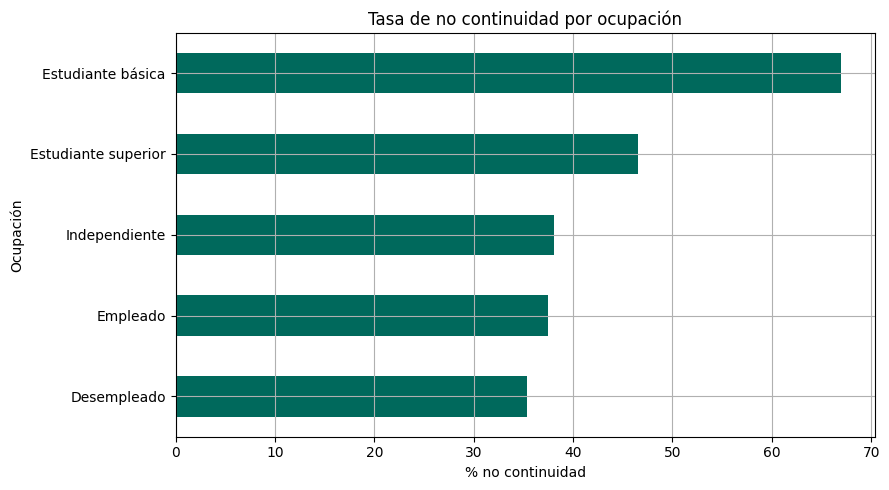

In [27]:
t19 = tasa_no_continuidad('Ocupación', min_n=50)
display(t19)
t19['Tasa_no_continuidad_%'].sort_values().plot(kind='barh', color='#00695c')
plt.title('Tasa de no continuidad por ocupación'); plt.xlabel('% no continuidad')
plt.tight_layout(); plt.show()

**Respuesta:** *Estudiante básica* tiene la tasa más alta (~67 %), mientras que *Empleado*, *Desempleado* e *Independiente* están alrededor del 35–38 %.

**Conclusión:** la ocupación discrimina el riesgo. *Hipótesis:* "Estudiante básica" coincide con la población de Media Técnica (artefacto ya mencionado); entre la población adulta, estar empleado se asocia a algo más de permanencia.

**Pregunta 20:** ¿El Nivel de formación se relaciona con la no continuidad?

In [28]:
t20 = tasa_no_continuidad('Nivel de formación', min_n=50)
display(t20)

,Estudiantes,Tasa_no_continuidad_%
Nivel de formación,,
Sin dato,3224,61.8
Básica secundaria,1892,51.1
Media,6098,40.9
Postgrado,76,40.8
Pregrado,458,36.9
Básica Secundaria,519,0.0


**Respuesta:** los niveles *Básica primaria/secundaria* muestran tasas más altas (~51–53 %) que *Media* y *Pregrado* (~41 %). La categoría *"Sin respuesta"* aparece con tasa alta, lo que es señal de calidad de datos más que de un patrón real.

**Conclusión:** a mayor nivel de formación previo, algo más de permanencia. *Hipótesis:* el capital educativo previo favorece la continuidad; los faltantes deben tratarse con cuidado para no sesgar el modelo.

---
# C. Análisis temporal

**Pregunta 21:** ¿Cómo ha evolucionado la matrícula a lo largo de los años?

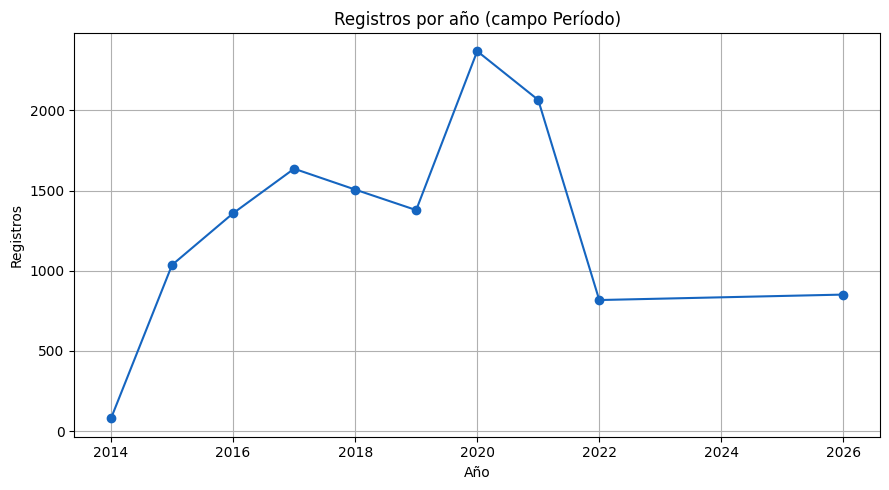

Anio_Periodo
2014.0      79
2015.0    1036
2016.0    1358
2017.0    1636
2018.0    1506
2019.0    1378
2020.0    2369
2021.0    2065
2022.0     817
2026.0     851
Name: count, dtype: int64

In [29]:
mat = df['Anio_Periodo'].value_counts().sort_index()
mat = mat[(mat.index >= 2014) & (mat.index <= 2026)]
mat.plot(kind='line', marker='o', color='#1565c0')
plt.title('Registros por año (campo Período)'); plt.xlabel('Año'); plt.ylabel('Registros')
plt.tight_layout(); plt.show()
mat

**Respuesta:** los registros se concentran entre 2014 y 2026, con volumen alto y sostenido entre 2017 y 2022. El último año puede verse incompleto por estar en curso.

**Conclusión:** hay masa histórica suficiente por año. *Hipótesis:* permite análisis por cohortes para ver si el riesgo cambia con el tiempo (Pregunta 22).

**Pregunta 22:** ¿Cómo ha evolucionado la tasa de no continuidad por año de período?

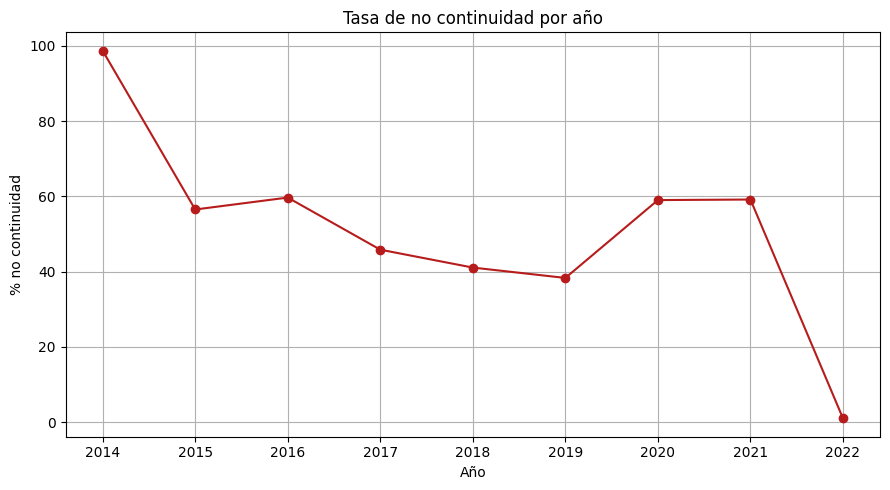

Anio_Periodo
2014.0    98.7
2015.0    56.5
2016.0    59.7
2017.0    45.8
2018.0    41.1
2019.0    38.3
2020.0    59.0
2021.0    59.2
2022.0     1.0
Name: Categoria, dtype: float64

In [30]:
coh = (clasif.groupby('Anio_Periodo')['Categoria']
       .apply(lambda s: (s == 'No continuidad').mean() * 100))
coh = coh[(coh.index >= 2014) & (coh.index <= 2025)]
coh.plot(kind='line', marker='o', color='#b71c1c')
plt.title('Tasa de no continuidad por año'); plt.xlabel('Año'); plt.ylabel('% no continuidad')
plt.tight_layout(); plt.show()
coh.round(1)

**Respuesta:** la tasa de no continuidad varía por año; los períodos más antiguos tienden a mostrar tasas más altas (los estudiantes ya tuvieron tiempo de cambiar de estado), mientras que los más recientes concentran más activos.

**Conclusión:** el "tiempo transcurrido" sesga la lectura por año. *Hipótesis:* para comparar cohortes de forma justa hay que considerar la antigüedad de cada período; fijar metas de reducción de deserción exige normalizar por este efecto.

---
# D. Calidad de datos y detección de anomalías

**Pregunta 23:** ¿Qué valores faltantes y anomalías presenta el dataset original?

Edad mínima en el archivo original (valor imposible): -973.0
Registros con edad <= 0: 19


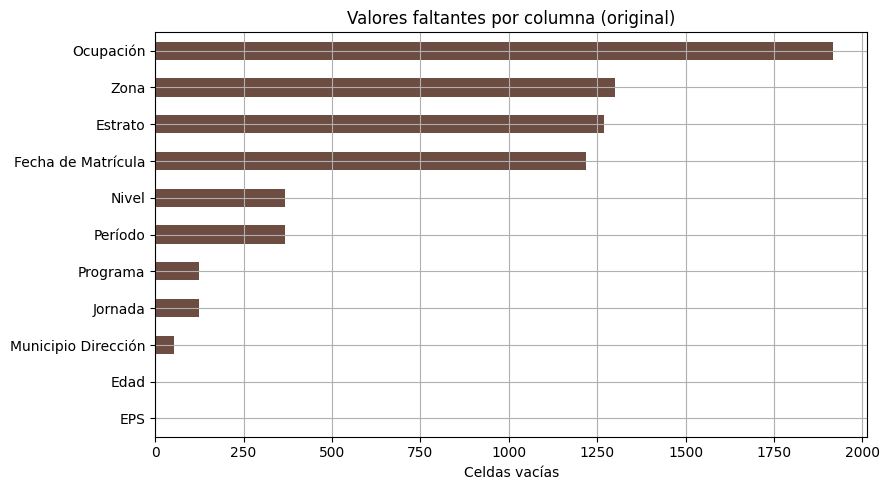

EPS                       1
Edad                      1
Municipio Dirección      54
Jornada                 123
Programa                123
Período                 366
Nivel                   366
Fecha de Matrícula     1217
Estrato                1268
Zona                   1301
Ocupación              1918
dtype: int64

In [31]:
orig = pd.read_csv(trusted_dir.replace('trusted', 'landing') + 'datos_consolidados.csv')
orig.columns = orig.columns.str.strip()
print('Edad mínima en el archivo original (valor imposible):', orig['Edad'].min())
print('Registros con edad <= 0:', int((orig['Edad'] <= 0).sum()))
falt = orig.isnull().sum(); falt = falt[falt > 0].sort_values()
falt.plot(kind='barh', color='#6d4c41')
plt.title('Valores faltantes por columna (original)'); plt.xlabel('Celdas vacías')
plt.tight_layout(); plt.show()
falt

**Respuesta:** se confirma al menos una **edad negativa** (≈ -973) y faltantes relevantes en *Ocupación*, *Zona*, *Estrato*, *Fecha de Matrícula* y *Período/Nivel*.

**Conclusión:** el dataset es usable pero exige depuración (ya aplicada en `02_limpieza`). *Hipótesis:* la calidad de datos es hoy el principal limitante del producto, más que el modelo en sí.

**Pregunta 24:** ¿Qué inconsistencias de categorías y duplicados existen?

In [32]:
print('Programas distintos:', df['Programa'].nunique())
print('\nNiveles de formación (ojo a duplicados por mayúsculas):')
print(df['Nivel de formación'].value_counts(dropna=False).head(8))

Programas distintos: 78

Niveles de formación (ojo a duplicados por mayúsculas):
Nivel de formación
Media                6819
Sin dato             3396
Básica secundaria    2102
Básica Secundaria     519
Pregrado              489
Postgrado              80
Básica primaria        38
Básica Primaria         9
Name: count, dtype: int64


**Respuesta:** hay **78 programas** (varios marcados como "antiguos" o duplicados), y categorías equivalentes escritas distinto, como *"Básica secundaria"* vs *"Básica Secundaria"*.

**Conclusión:** se requiere homologación de programas y niveles. *Hipótesis:* estandarizar estas categorías reducirá el ruido y mejorará tanto el EDA como el modelo.

---
# E. Análisis de correlación
Identificar las variables con mayor impacto sobre la variable objetivo, para el modelo de `04_modelo`.

In [33]:
# Codificamos la variable objetivo y algunas variables para medir correlación
modelo_df = clasif.copy()
modelo_df['no_continuidad'] = (modelo_df['Categoria'] == 'No continuidad').astype(int)
modelo_df['genero_cod'] = modelo_df['Género'].map({'Femenino': 0, 'Masculino': 1})

num_cols = ['Edad', 'Estrato', 'Anio_Periodo', 'genero_cod', 'no_continuidad']
corr = modelo_df[num_cols].corr()
corr.round(2)

,Edad,Estrato,Anio_Periodo,genero_cod,no_continuidad
Edad,1.00,0.04,-0.18,-0.10,-0.18
Estrato,0.04,1.00,-0.00,0.06,0.04
Anio_Periodo,-0.18,-0.00,1.00,-0.12,-0.24
genero_cod,-0.10,0.06,-0.12,1.00,0.10
no_continuidad,-0.18,0.04,-0.24,0.10,1.00


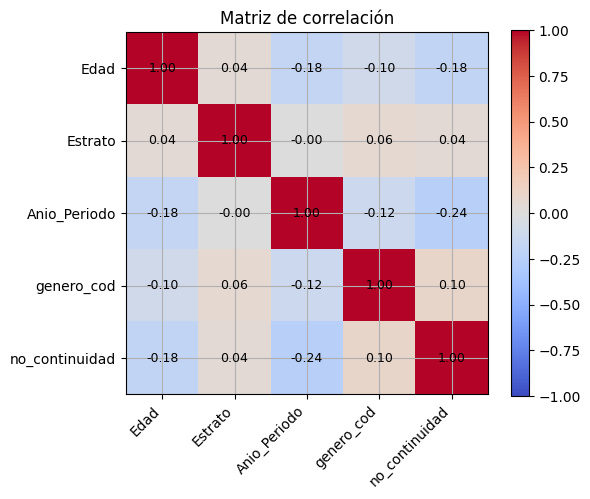

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im); plt.title('Matriz de correlación'); plt.tight_layout(); plt.show()

**Respuesta:** las correlaciones lineales con `no_continuidad` son **débiles** (edad y género con signo esperado pero magnitud baja). Esto es normal: la señal más fuerte está en variables **categóricas** (jornada y programa), que no se capturan bien con correlación de Pearson.

**Conclusión:** no basta con correlaciones lineales para seleccionar variables. *Hipótesis:* el modelo debe incluir programa y jornada (vía codificación categórica), que en el EDA mostraron el mayor poder de separación; edad, género y estrato entran como variables de apoyo.

**Último paso:** guardar los datos analizados y listos para entrenar el modelo de ML.

In [35]:
# Conservamos solo registros clasificables y las columnas útiles para el modelo
columnas_ml = ['Género', 'Edad', 'Estrato', 'Zona', 'Ocupación', 'Nivel de formación',
               'Jornada', 'Programa', 'Anio_Periodo', 'Categoria']
ml = clasif[columnas_ml].copy()
ml['no_continuidad'] = (ml['Categoria'] == 'No continuidad').astype(int)
ml.to_csv(trusted_dir + 'datos_limpios_ml.csv', index=False)
print('Guardado data/trusted/datos_limpios_ml.csv ->', ml.shape)
ml.head()

Guardado data/trusted/datos_limpios_ml.csv -> (12323, 11)


,Género,Edad,Estrato,Zona,Ocupación,Nivel de formación,Jornada,Programa,Anio_Periodo,Categoria,no_continuidad
0,Femenino,20.0,3.0,Urbana,Estudiante básica,Básica secundaria,MEDIA TÉCNICA,MEDIA TÉCNICA TECNICO LABORAL AUXILIAR ADMINIS...,2018.0,Continuidad,0
1,Femenino,29.0,2.0,Urbana,Estudiante superior,Media,NOCHE,10T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO...,2016.0,Continuidad,0
2,Masculino,19.0,3.0,Rural,Estudiante superior,Media,NOCHE,09T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,2021.0,No continuidad,1
3,Masculino,21.0,2.0,Urbana,Estudiante superior,Media,DIURNA,01T-TÉCNICO LABORAL AUXILIAR DE TALENTO HUMANO,2021.0,Continuidad,0
4,Masculino,20.0,2.0,Urbana,Estudiante superior,Media,NOCHE,27T-TÉCNICO LABORAL EN MERCADEO Y VENTAS (Estu...,2020.0,No continuidad,1
